# Image → caption with masked diffusion

A small, readable **inference** notebook. We use pretrained **LaViDa-LLaDA** to turn an image into a short caption and display the actual intermediate token states. We do not train a large model here.

**Pipeline:** image → visual features → guide a masked text denoiser → caption.

The image stays uncorrupted. Only the output text starts masked. This is **discrete masked diffusion**, not Gaussian noise added to a VAE image latent, and not a left-to-right caption generator.


## 1. Install the model's compatible libraries

We keep Kaggle's existing PyTorch/CUDA installation. The Transformers version matches the checkpoint configuration. Run this cell before importing Transformers. If you already imported a different version, restart the kernel after installation.

In [1]:
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.50.3", "accelerate==1.6.0",
    "bitsandbytes==0.45.5", "Pillow>=10,<12", "pandas>=2,<3"
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


0

## 2. Check the GPU and choose an image



GPU: Tesla T4; total memory: 14.6 GiB
Computation dtype: torch.bfloat16


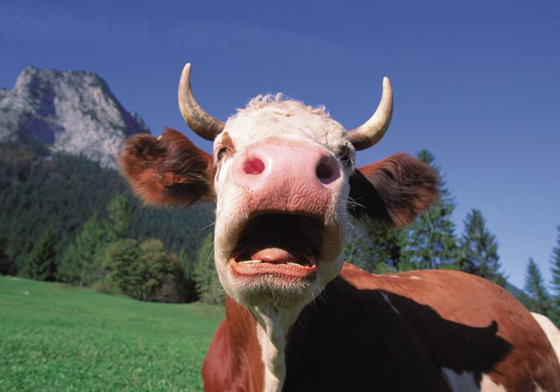

Original image size: (736, 515)


In [2]:
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
import torch
import pandas as pd
from PIL import Image, ImageOps
from IPython.display import display

if not torch.cuda.is_available():
    raise RuntimeError("Enable a GPU in Kaggle's notebook settings, then restart and rerun.")

DEVICE = "cuda:0"
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}; total memory: {gpu.total_memory / 2**30:.1f} GiB")
print("Computation dtype:", DTYPE)
#u can use your desired image here or else use the notebook's default dog picture! 
IMAGE_PATH = "/kaggle/input/datasets/sabast/cowwww/1231231231.jpg"  
DEMO_URL = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

if IMAGE_PATH:
    path = Path(IMAGE_PATH)
    if not path.is_file():
        raise FileNotFoundError(f"Set IMAGE_PATH to an existing image file: {path}")
    image = Image.open(path)
    image_source = str(path)
else:
    with urlopen(DEMO_URL, timeout=60) as response:
        image = Image.open(BytesIO(response.read()))
    image_source = DEMO_URL

image = ImageOps.exif_transpose(image).convert("RGB")
preview = image.copy()
preview.thumbnail((560, 560))
display(preview)
print("Original image size:", image.size)

## 3. Load the pretrained diffusion captioner

LaViDa combines a **SigLIP vision encoder**, a learned projector, and a **LLaDA masked diffusion language model**. The image features are projected into the language model's embedding width so attention can combine them with text. This does not mean that image and text started in one shared compressed space.

**Where is CLIP?** This checkpoint uses SigLIP, a related vision-language encoder, rather than the original CLIP. Its image encoder supplies visual patch features. The projector maps those features to the text embedding width, and they are inserted into the sequence attended to by the diffusion language model. This particular fusion uses sequence insertion and attention, not a separate cross-attention module. There is no image decoder because our output is text.

The checkpoint uses custom Python model code, loaded with `trust_remote_code=True` from the pinned revision below. We quantize language-model linear layers to 4 bits but leave the vision encoder, projector, and final output head at ordinary floating-point precision. Quantization can change predictions.

This is the slowest setup cell. Do not call `model.to(...)` on the whole quantized model afterward.

In [3]:
from transformers import AutoTokenizer, AutoConfig, BitsAndBytesConfig
from transformers.dynamic_module_utils import get_class_from_dynamic_module
import json
import sys
from huggingface_hub import hf_hub_download

MODEL_ID = "KonstantinosKK/lavida-llada-v1.0-instruct-hf-transformers"
REVISION = "6abbe20c941741ecd5c5189af81deb6c1b0735fc"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=REVISION)
quantization = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=DTYPE,
    llm_int8_skip_modules=[
        "vision_tower", "mm_projector", "model.transformer.ff_out"
    ],
)

# Confirm that this pinned checkpoint contains the trained vision weights.
index_path = hf_hub_download(MODEL_ID, "model.safetensors.index.json", revision=REVISION)
with open(index_path) as handle:
    weight_names = json.load(handle)["weight_map"]
vision_prefix = "model.vision_tower.vision_tower."
if not any(name.startswith(vision_prefix) for name in weight_names):
    raise RuntimeError("This loading fix requires a checkpoint containing vision weights.")

config = AutoConfig.from_pretrained(
    MODEL_ID, revision=REVISION, trust_remote_code=True
)
ModelClass = get_class_from_dynamic_module(
    config.auto_map["AutoModelForCausalLM"], MODEL_ID, revision=REVISION
)
model_module = sys.modules[ModelClass.__module__]

def initialize_vision_structure(self, device_map=None):
    # The outer from_pretrained call will load the actual trained weights.
    # Avoid a second from_pretrained call inside its empty-weight context.
    if self.is_loaded:
        return
    self.vision_tower = model_module.SigLipVisionModel(self.config)
    del self.vision_tower.vision_model.encoder.layers[-1:]
    self.vision_tower.vision_model.head = torch.nn.Identity()
    self.vision_tower.requires_grad_(False)
    self.is_loaded = True

original_vision_loader = model_module.SigLipVisionTower.load_model
model_module.SigLipVisionTower.load_model = initialize_vision_structure
try:
    model, loading_info = ModelClass.from_pretrained(
        MODEL_ID,
        revision=REVISION,
        config=config,
        torch_dtype=DTYPE,
        quantization_config=quantization,
        device_map={"": DEVICE},
        low_cpu_mem_usage=True,
        output_loading_info=True,
    )
finally:
    model_module.SigLipVisionTower.load_model = original_vision_loader

missing_vision = [name for name in loading_info.get("missing_keys", [])
                  if name.startswith(vision_prefix)]
unmaterialized = [name for name, param in model.named_parameters() if param.is_meta]
unmaterialized += [name for name, buf in model.named_buffers() if buf.is_meta]
if missing_vision or unmaterialized:
    raise RuntimeError(
        f"Incomplete model load: missing vision weights={missing_vision[:5]}; "
        f"meta tensors={unmaterialized[:5]}"
    )
model.eval()
vision_tower = model.get_vision_tower()
image_processor = vision_tower.image_processor
print("Loaded:", model.__class__.__name__)
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 2**30:.2f} GiB")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading vision tower: google/siglip-so400m-patch14-384


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

Loaded: LlavaLladaForMaskedDiffusion
GPU memory allocated: 6.07 GiB


## 4. Prepare the image and the instruction

For readability and lower memory use, this notebook uses the model's supported **single resized image** path. The processor makes one 384 × 384 view; this can lose fine details or distort the aspect ratio. The official high-resolution multi-crop pipeline is more elaborate and is not reproduced here.

The image becomes patch features. An `<image>` placeholder tells the model where to insert those features into the prompt. It is replaced by visual embeddings, not treated as a normal word.

The following helper inserts the checkpoint's special image sentinel while preserving the tokenizer's beginning-of-sequence handling.

In [4]:
IMAGE_TOKEN_INDEX = -200

def image_prompt_ids(prompt, tokenizer):
    """Tokenize a prompt containing exactly one image placeholder."""
    if prompt.count("<image>") != 1:
        raise ValueError("Expected exactly one <image> placeholder.")
    left, right = [tokenizer(part).input_ids for part in prompt.split("<image>")]
    has_bos = bool(left) and left[0] == tokenizer.bos_token_id
    offset = 1 if has_bos else 0
    ids = ([left[0]] if has_bos else []) + left[offset:]
    ids += [IMAGE_TOKEN_INDEX] + right[offset:]
    return ids

messages = [
    {"role": "system", "content": (
        "You are a helpful language and vision assistant. "
        "You are able to understand the visual content that the user provides, "
        "and assist the user with a variety of tasks using natural language."
    )},
    {"role": "user", "content": "<image>\nDescribe this image in one short sentence."},
]
prompt = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
input_ids = torch.tensor([image_prompt_ids(prompt, tokenizer)], device=DEVICE)
pixels = image_processor.preprocess(image, return_tensors="pt")["pixel_values"]
pixels = pixels.to(device=DEVICE, dtype=DTYPE)

assert pixels.ndim == 4 and pixels.shape[0] == 1
assert int((input_ids == IMAGE_TOKEN_INDEX).sum()) == 1
print("Image tensor:", tuple(pixels.shape), "= batch, channels, height, width")
print("Prompt token count (before image-feature insertion):", input_ids.shape[1])
print("No noise or masking has been applied to the image.")

Image tensor: (1, 3, 384, 384) = batch, channels, height, width
Prompt token count (before image-feature insertion): 63
No noise or masking has been applied to the image.


## 5. Generate a caption by filling masks

We reserve 32 output token positions and fill them over 16 denoising steps. Tokens may be word fragments; 32 tokens is not necessarily 32 words.

At each step, the network predicts tokens at the remaining masked positions. The sampler commits the most confident predictions. With these settings, it normally commits two positions per step, which need not be adjacent or left-to-right. Already committed positions stay fixed in this particular sampler.

`verbose=True` asks this custom implementation to return the actual intermediate token IDs. `prefix_lm=False` avoids its unsupported cache path. Despite the Hugging Face loader being named `AutoModelForCausalLM`, this checkpoint overrides generation with masked diffusion.

Actual feature shapes (batch, image patches, feature width): {'vision_features': (1, 729, 1152), 'projected_features': (1, 729, 4096)}


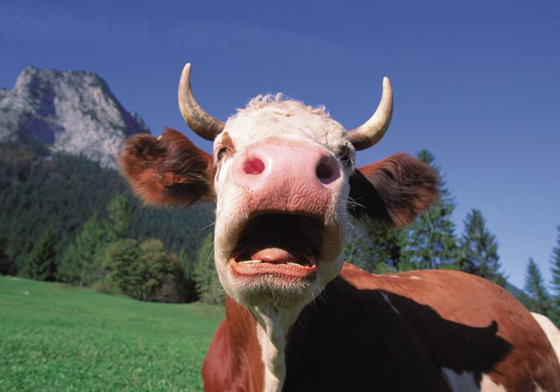

Caption: A cow with a big face in front the mountains.
Peak allocated GPU memory: 8.62 GiB


In [5]:
MAX_TOKENS = 32
DENOISING_STEPS = 16
assert 1 <= DENOISING_STEPS <= MAX_TOKENS

torch.manual_seed(7)
torch.cuda.reset_peak_memory_stats()
feature_shapes = {}
def record_feature_shapes(module, args, output):
    feature_shapes["vision_features"] = tuple(args[0].shape)
    feature_shapes["projected_features"] = tuple(output.shape)

hook = model.get_model().mm_projector.register_forward_hook(record_feature_shapes)
try:
    with torch.inference_mode():
        generated_ids, history = model.generate(
            inputs=input_ids,
            images=pixels,
            image_sizes=[image.size],
            max_new_tokens=MAX_TOKENS,
            block_length=MAX_TOKENS,
            steps=DENOISING_STEPS,
            temperature=0.0,
            remasking="low_confidence",
            prefix_lm=False,
            verbose=True,
            tokenizer=tokenizer,
        )
finally:
    hook.remove()

print("Actual feature shapes (batch, image patches, feature width):", feature_shapes)

# Uncached generation includes placeholder IDs for the visual/text prefix.
# Only the final MAX_TOKENS positions are generated caption tokens.
answer_ids = generated_ids[0, -MAX_TOKENS:].detach().cpu().tolist()
MASK_ID = model.config.mask_token_id
if MASK_ID in answer_ids:
    raise RuntimeError("Unfilled masks remain. Inspect the sampling settings and history.")

def trim_at_end(token_ids, tokenizer):
    """Remove padding/extra text after the first end-of-turn or end-of-text token."""
    end_ids = {tokenizer.eos_token_id}
    for token in ("<|eot_id|>", "<|endoftext|>"):
        token_id = tokenizer.get_vocab().get(token)
        if token_id is not None:
            end_ids.add(token_id)
    for i, token_id in enumerate(token_ids):
        if token_id in end_ids:
            return token_ids[:i]
    return token_ids

caption = tokenizer.decode(
    trim_at_end(answer_ids, tokenizer), skip_special_tokens=True
).strip()
display(preview)
print("Caption:", caption or "[Empty caption: inspect the history below.]")
print(f"Peak allocated GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB")

## 6. Inspect every denoising step

The first row is the all-mask starting state. Subsequent rows are recorded model states, not a fabricated animation. We keep end markers visible because masking and special tokens can otherwise look like blank text. Text after an end marker is discarded from the final caption.

In [6]:
mask_text = tokenizer.decode([MASK_ID], skip_special_tokens=False)

def readable_state(ids):
    return tokenizer.decode(ids, skip_special_tokens=False).replace(mask_text, " [MASK] ")

records = [{"step": 0, "masks_left": MAX_TOKENS,
            "text_state": " ".join(["[MASK]"] * MAX_TOKENS)}]
for step, snapshot in enumerate(history, start=1):
    ids = snapshot[0, -MAX_TOKENS:].tolist()
    records.append({
        "step": step,
        "masks_left": ids.count(MASK_ID),
        "text_state": readable_state(ids),
    })

trace = pd.DataFrame(records)
with pd.option_context("display.max_colwidth", None, "display.max_rows", 40):
    display(trace)

counts = trace["masks_left"].tolist()
assert counts[0] == MAX_TOKENS and counts[-1] == 0
assert all(a >= b for a, b in zip(counts, counts[1:]))
print("The image is fixed; the number of masked caption positions decreases.")

,step,masks_left,text_state
0,0,32,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]
1,1,30,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|>
2,2,28,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|>
3,3,26,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
4,4,24,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
5,5,22,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
6,6,20,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
7,7,18,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
8,8,16,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
9,9,14,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>


The image is fixed; the number of masked caption positions decreases.


## 7. What learning happened before we loaded this model?

The pretrained model has already learned from image–text examples. A simplified masked-diffusion training exercise is:

1. Encode an image (I) into visual features (V).
2. Take its true caption (y_0).
3. Draw a noise level (t), and independently replace some caption tokens by `[MASK]` to get (y_t).
4. Predict the original tokens from (y_t) and (V).
5. Penalize incorrect predictions at **masked caption positions** and update the trainable weights using backpropagation.

A basic form of the objective is

\[
\mathcal L = \mathbb E_{t,y_t}\left[w(t)\sum_{i\in M_t}-\log p_\theta(y_{0,i}\mid y_t,V)\right].
\]

(M_t) means the masked positions, and (w(t)) weights noise levels according to the training formulation. Published systems include additional details; this is the core learning idea, not a reproduction of LaViDa's complete training recipe.

**Training:** correct captions are available and weights change. **This notebook's generation:** no correct caption is supplied and the weights stay fixed.

The next cell illustrates caption corruption only. It does not train or fine-tune the loaded model. Word-level splitting is used solely to make the demonstration easy to read; the real model uses its own tokenizer.

In [7]:
import random

words = "a dog is running on grass".split()
rng = random.Random(7)
thresholds = [rng.random() for _ in words]
for mask_probability in (0.0, 0.25, 0.5, 0.75, 1.0):
    corrupted = [
        "[MASK]" if u < mask_probability else word
        for word, u in zip(words, thresholds)
    ]
    print(f"Mask probability {mask_probability:.2f}: {' '.join(corrupted)}")

Mask probability 0.00: a dog is running on grass
Mask probability 0.25: a [MASK] is [MASK] on grass
Mask probability 0.50: [MASK] [MASK] is [MASK] on [MASK]
Mask probability 0.75: [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]
Mask probability 1.00: [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]


## 8. Save the result

The JSON includes the caption, settings, image source, and actual denoising trace for comparison after another run.

In [8]:
import json

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
output_path = output_dir / "diffusion_caption_result.json"
result = {
    "caption": caption,
    "image_source": image_source,
    "model": MODEL_ID,
    "revision": REVISION,
    "max_tokens": MAX_TOKENS,
    "denoising_steps": DENOISING_STEPS,
    "quantized_4bit": True,
    "image_preprocessing": "single resized 384x384 view",
    "trace": records,
}
output_path.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
print("Saved:", output_path)

Saved: /kaggle/working/diffusion_caption_result.json
